### Ensemble machine learning algorithm

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

In [3]:
df=pd.read_csv("C:/Fusion/DS_f/Datasets/placementdata.csv")

In [5]:
df.head()

,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,SSC_Marks,HSC_Marks,PlacementStatus
0,1,7.5,1,1,1,65,4.4,61,79,NotPlaced
1,2,8.9,0,3,2,90,4.0,78,82,Placed
2,3,7.3,1,2,2,82,4.8,79,80,NotPlaced
3,4,7.5,1,1,2,85,4.4,81,80,Placed
4,5,8.3,1,2,2,86,4.5,74,88,Placed


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   StudentID                 10000 non-null  int64  
 1   CGPA                      10000 non-null  float64
 2   Internships               10000 non-null  int64  
 3   Projects                  10000 non-null  int64  
 4   Workshops/Certifications  10000 non-null  int64  
 5   AptitudeTestScore         10000 non-null  int64  
 6   SoftSkillsRating          10000 non-null  float64
 7   SSC_Marks                 10000 non-null  int64  
 8   HSC_Marks                 10000 non-null  int64  
 9   PlacementStatus           10000 non-null  object 
dtypes: float64(2), int64(7), object(1)
memory usage: 781.4+ KB


In [70]:
df.describe()

,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,SSC_Marks,HSC_Marks
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,7.698010,1.049200,2.026600,1.013200,79.449900,4.323960,69.159400,74.501500
std,2886.89568,0.640131,0.665901,0.867968,0.904272,8.159997,0.411622,10.430459,8.919527
min,1.00000,6.500000,0.000000,0.000000,0.000000,60.000000,3.000000,55.000000,57.000000
25%,2500.75000,7.400000,1.000000,1.000000,0.000000,73.000000,4.000000,59.000000,67.000000
50%,5000.50000,7.700000,1.000000,2.000000,1.000000,80.000000,4.400000,70.000000,73.000000
75%,7500.25000,8.200000,1.000000,3.000000,2.000000,87.000000,4.700000,78.000000,83.000000
max,10000.00000,9.100000,2.000000,3.000000,3.000000,90.000000,4.800000,90.000000,88.000000


In [151]:
df.isna().sum()

StudentID                   0
CGPA                        0
Internships                 0
Projects                    0
Workshops/Certifications    0
AptitudeTestScore           0
SoftSkillsRating            0
SSC_Marks                   0
HSC_Marks                   0
PlacementStatus             0
dtype: int64

In [11]:
# Separate features and target
x = df.drop(columns=["StudentID","PlacementStatus"])
y = df["PlacementStatus"]
y

0       NotPlaced
1          Placed
2       NotPlaced
3          Placed
4          Placed
          ...    
9995    NotPlaced
9996       Placed
9997       Placed
9998       Placed
9999    NotPlaced
Name: PlacementStatus, Length: 10000, dtype: object

In [157]:
y.value_counts()

PlacementStatus
NotPlaced    5803
Placed       4197
Name: count, dtype: int64

In [1]:
from imblearn.over_sampling import RandomOverSampler 
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter
# Apply Oversampling
rus = RandomOverSampler()
X1,Y1 = rus.fit_resample(x, y)

print(Counter(Y1))

NameError: name 'x' is not defined

In [29]:
# Split the data into training and testing sets
xtrain, xtest, ytrain, yactual = train_test_split(x,y , test_size=0.1)

In [21]:
xtrain.shape

(10445, 8)

In [23]:
xtest.shape

(1161, 8)

In [31]:
# Train the Decision Tree model
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
dtmodel = DecisionTreeClassifier()
dtmodel.fit(xtrain, ytrain)

# Make predictions on the test data
ypred = dtmodel.predict(xtest)

# Evaluate the model
print("Accuracy is:", accuracy_score(yactual, ypred) ,'\n')
# Classification Report
print(classification_report(yactual, ypred))

Accuracy is: 0.727 

              precision    recall  f1-score   support

   NotPlaced       0.77      0.75      0.76       583
      Placed       0.67      0.70      0.68       417

    accuracy                           0.73      1000
   macro avg       0.72      0.72      0.72      1000
weighted avg       0.73      0.73      0.73      1000



In [33]:
cm= confusion_matrix(yactual,ypred)
cm

array([[437, 146],
       [127, 290]], dtype=int64)

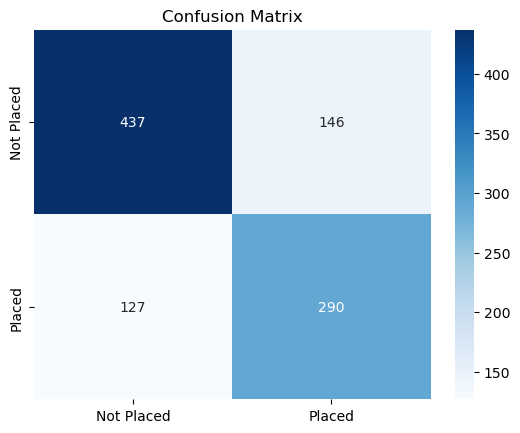

In [37]:
#fmt="d"
sns.heatmap(cm, annot=True,fmt="d", cmap="Blues", xticklabels=["Not Placed", "Placed"], yticklabels=["Not Placed", "Placed"])
plt.title("Confusion Matrix")
plt.show()

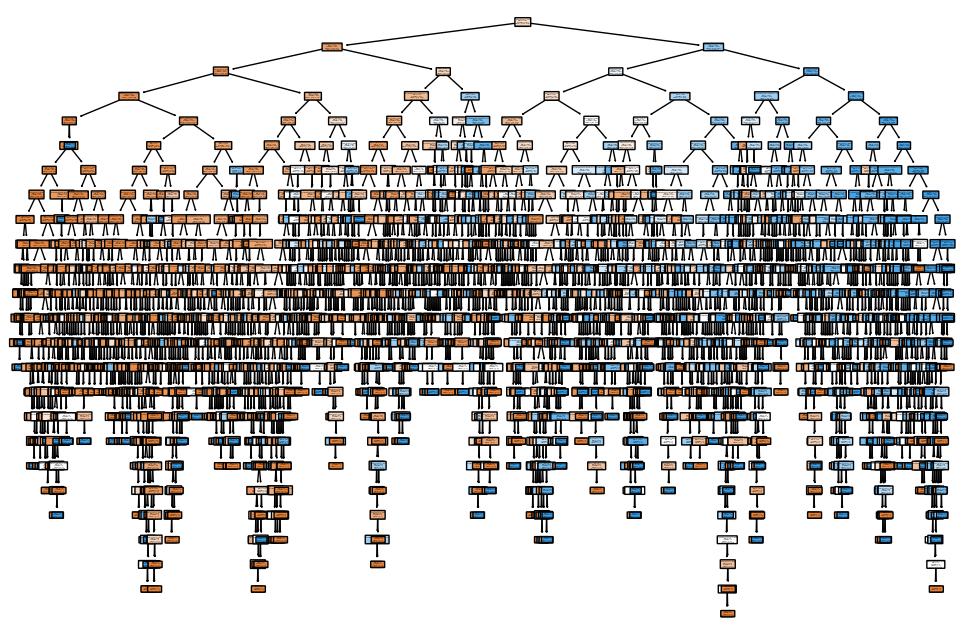

In [39]:
# Visualize the decision tree
# A graphical representation of your trained decision tree will be shown.
plt.figure(figsize=(12, 8))
plot_tree(dtmodel, filled=True, feature_names=x.columns, class_names=["Not Placed", "Placed"], rounded=True)
plt.show()

#filled=True: Color the nodes based on class.
#feature_names: Use the names of the features for splitting.
#class_names: Show the names of the classes in the leaf nodes.
#rounded=True: Round the corners of the nodes for better visuals.

In [41]:
df2= pd.read_csv("C:/Fusion/Datasets/iris_1.csv")
df2.head()

,Unnamed: 0,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,1,5.1,3.5,1.4,0.2,setosa
1,2,4.9,3.0,1.4,0.2,setosa
2,3,4.7,3.2,1.3,0.2,setosa
3,4,4.6,3.1,1.5,0.2,setosa
4,5,5.0,3.6,1.4,0.2,setosa


In [43]:
df2.isna().sum().sum()

0

In [45]:
# Separate features and target
x = df2.drop(columns=["Unnamed: 0","Species"])
y = df2["Species"]

# Split the data into training and testing sets
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.1, random_state=10)

In [47]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
m1=DecisionTreeClassifier().fit(xtrain,ytrain)
m1

DecisionTreeClassifier()

In [49]:
p1=m1.predict(xtest)
p1

array(['versicolor', 'virginica', 'setosa', 'versicolor', 'setosa',
       'versicolor', 'versicolor', 'versicolor', 'setosa', 'versicolor',
       'versicolor', 'virginica', 'versicolor', 'setosa', 'setosa'],
      dtype=object)

In [51]:
# Evaluate the model
print("Accuracy is:", accuracy_score(ytest, p1) ,'\n')

Accuracy is: 1.0 



In [53]:
CM= confusion_matrix(ytest,p1)
CM

array([[5, 0, 0],
       [0, 8, 0],
       [0, 0, 2]], dtype=int64)

In [190]:
y.value_counts()

Species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [73]:
x.columns

Index(['Sepal.Length', 'Sepal.Width', 'Petal.Length', 'Petal.Width'], dtype='object')

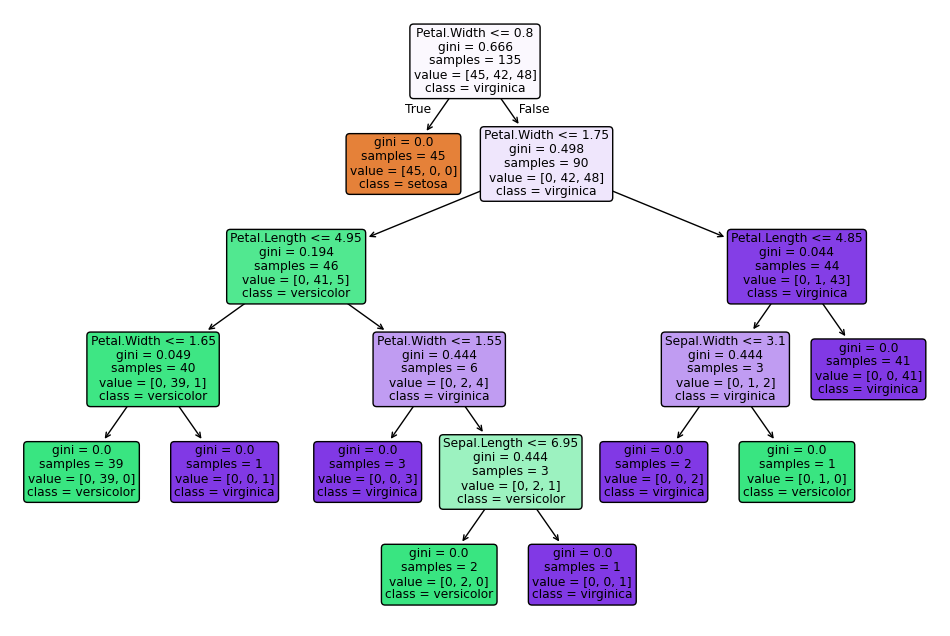

In [55]:
plt.figure(figsize=(12, 8))
plot_tree(m1, filled=True, feature_names=x.columns, class_names=["setosa", "versicolor","virginica"], rounded=True)
plt.show()

In [5]:
df2= pd.read_csv("C:/Fusion/Datasets/iris_1.csv")
df2.head()
# Separate features and target
x = df2.drop(columns=["Unnamed: 0","Species"])
y = df2["Species"]

# Split the data into training and testing sets
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.1, random_state=40)

In [128]:
df.head()

,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,SSC_Marks,HSC_Marks,PlacementStatus
0,1,7.5,1,1,1,65,4.4,61,79,NotPlaced
1,2,8.9,0,3,2,90,4.0,78,82,Placed
2,3,7.3,1,2,2,82,4.8,79,80,NotPlaced
3,4,7.5,1,1,2,85,4.4,81,80,Placed
4,5,8.3,1,2,2,86,4.5,74,88,Placed


In [9]:
# Split the data into training and testing sets
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.1, random_state=40)

accuracy is : 0.791
              precision    recall  f1-score   support

   NotPlaced       0.83      0.81      0.82       577
      Placed       0.74      0.77      0.76       423

    accuracy                           0.79      1000
   macro avg       0.79      0.79      0.79      1000
weighted avg       0.79      0.79      0.79      1000



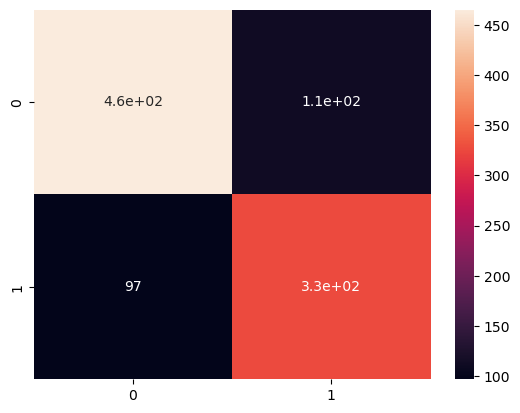

In [17]:
#Bagging Meta Estimator Classifier
from sklearn.ensemble import RandomForestClassifier,RandomForestRegressor
#making the bagging classifier with 500 decision trees # n_estimators=500
Rmodel=RandomForestClassifier(n_estimators=500)

#fitting data to bagging model
Rmodel.fit(xtrain,ytrain)
#testing on test dataset 
ypred=Rmodel.predict(xtest)
#Model Evaluation 
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print("accuracy is :",accuracy_score(ytest,ypred))
cm=confusion_matrix(ytest,ypred)
sns.heatmap(cm,annot=True)
print(classification_report(ytest,ypred))

accuracy is : 0.812
              precision    recall  f1-score   support

   NotPlaced       0.85      0.82      0.84       577
      Placed       0.77      0.79      0.78       423

    accuracy                           0.81      1000
   macro avg       0.81      0.81      0.81      1000
weighted avg       0.81      0.81      0.81      1000



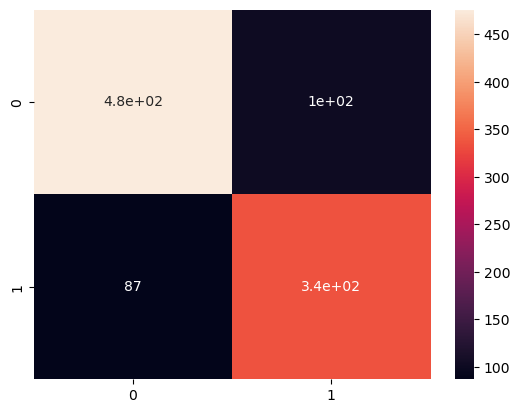

In [21]:
#Bagging Meta Estimator Classifier
from sklearn.ensemble import BaggingClassifier
from sklearn.linear_model import LogisticRegression
#making the bagging classifier with 500 Logistic Regression models
B2model=BaggingClassifier(estimator=LogisticRegression(),n_estimators=500)

#bagging classifier with 500 decision trees
#B1model=BaggingClassifier(n_estimators=500)
#fitting data to bagging model
B2model.fit(xtrain,ytrain)
#testing on test dataset 
ypred=B2model.predict(xtest)
#Model Evaluation 
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print("accuracy is :",accuracy_score(ytest,ypred))
cm=confusion_matrix(ytest,ypred)
sns.heatmap(cm,annot=True)
print(classification_report(ytest,ypred))

accuracy is : 0.7717484926787253
              precision    recall  f1-score   support

   NotPlaced       0.76      0.79      0.77       576
      Placed       0.79      0.75      0.77       585

    accuracy                           0.77      1161
   macro avg       0.77      0.77      0.77      1161
weighted avg       0.77      0.77      0.77      1161



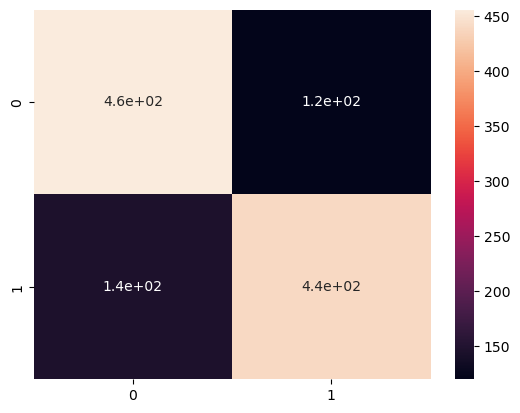

In [140]:
#Bagging Meta Estimator Classifier
from sklearn.ensemble import BaggingClassifier
from sklearn.svm import SVC
#making the bagging classifier with 500 Logistic Regression models
B1model=BaggingClassifier(estimator=SVC(),n_estimators=500)

#fitting data to bagging model
B1model.fit(xtrain,ytrain)
#testing on test dataset 
ypred=B1model.predict(xtest)
#Model Evaluation 
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print("accuracy is :",accuracy_score(ytest,ypred))
cm=confusion_matrix(ytest,ypred)
sns.heatmap(cm,annot=True)
print(classification_report(ytest,ypred))

## Gradient Boosting (GBM)

Gradient Boosting or GBM is another ensemble machine learning algorithm that works for both regression and classification problems. GBM uses the boosting technique, combining a number of weak learners to form a strong learner. Regression trees used as a base learner, each subsequent tree in series is built on the errors calculated by the previous tree.


In [67]:
xtest.shape

(2000, 9)

In [66]:
xtrain.shape

(8000, 9)

In [69]:
df['PlacementStatus'].value_counts()

PlacementStatus
NotPlaced    5803
Placed       4197
Name: count, dtype: int64

Accuracy is : 0.79
              precision    recall  f1-score   support

   NotPlaced       0.83      0.80      0.81       577
      Placed       0.74      0.78      0.76       423

    accuracy                           0.79      1000
   macro avg       0.79      0.79      0.79      1000
weighted avg       0.79      0.79      0.79      1000



<Axes: >

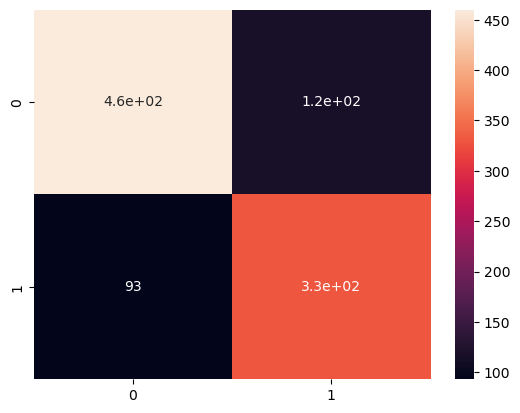

In [11]:
from sklearn.ensemble import GradientBoostingClassifier,GradientBoostingRegressor
model = GradientBoostingClassifier(n_estimators=500)  # n_estimators= DT
model.fit(xtrain, ytrain)
ypred=model.predict(xtest)

from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
print("Accuracy is :",accuracy_score(ytest,ypred))
print(classification_report(ytest,ypred))
cm=confusion_matrix(ytest,ypred)
cm
sns.heatmap(cm,annot=True)

## AdaBoost

Adaptive boosting or AdaBoost is one of the simplest boosting algorithms. Usually, decision trees are used for modelling. Multiple sequential models are created, each correcting the errors from the last model. AdaBoost assigns weights to the observations which are incorrectly predicted and the subsequent model works to predict these values correctly.

Below are the steps for performing the AdaBoost algorithm:

    1.Initially, all observations in the dataset are given equal weights.
    2.A model is built on a subset of data.
    3.Using this model, predictions are made on the whole dataset.
    4.Errors are calculated by comparing the predictions and actual values.
    5.While creating the next model, higher weights are given to the data points which were predicted incorrectly.
    6.Weights can be determined using the error value. For instance, higher the error more is the weight assigned to the observation.
    7.This process is repeated until the error function does not change, or the maximum limit of the number of estimators is reached.


In [13]:
from sklearn.ensemble import AdaBoostClassifier
model_1 = AdaBoostClassifier(n_estimators=500)
model_1.fit(xtrain, ytrain)

AdaBoostClassifier(n_estimators=500)

Accuracy is : 0.801
              precision    recall  f1-score   support

   NotPlaced       0.84      0.81      0.82       577
      Placed       0.75      0.79      0.77       423

    accuracy                           0.80      1000
   macro avg       0.80      0.80      0.80      1000
weighted avg       0.80      0.80      0.80      1000



<Axes: >

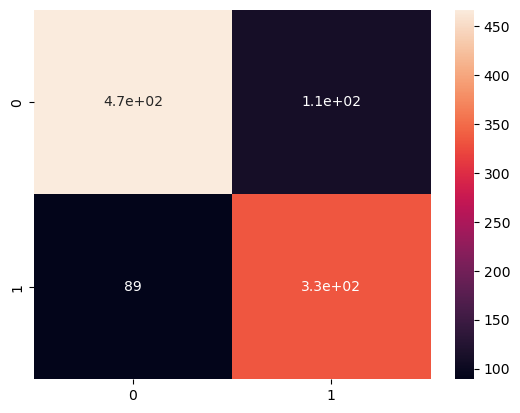

In [14]:
ypred=model_1.predict(xtest)
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
print("Accuracy is :",accuracy_score(ytest,ypred))
print(classification_report(ytest,ypred))
cm=confusion_matrix(ytest,ypred)
cm
sns.heatmap(cm,annot=True)

XGBoost (Extreme Gradient Boosting) is a popular machine learning algorithm that is widely used for classification and regression tasks due to its high performance and efficiency. Below is an implementation of XGBoost in Python using the xgboost package.

In [17]:
#pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [54]:
df=pd.read_csv("C:/Fusion/DS_f/Datasets/placementdata.csv")
x = df.drop(columns=["PlacementStatus"])
y1 = df["PlacementStatus"]
y1

0       NotPlaced
1          Placed
2       NotPlaced
3          Placed
4          Placed
          ...    
9995    NotPlaced
9996       Placed
9997       Placed
9998       Placed
9999    NotPlaced
Name: PlacementStatus, Length: 10000, dtype: object

In [56]:
x.columns

Index(['StudentID', 'CGPA', 'Internships', 'Projects',
       'Workshops/Certifications', 'AptitudeTestScore', 'SoftSkillsRating',
       'SSC_Marks', 'HSC_Marks'],
      dtype='object')

In [19]:
#pip install xgboost
import xgboost as xgb

# Load dataset
df=pd.read_csv("C:/Fusion/DS_f/Datasets/placementdata.csv")
x = df.drop(columns=["StudentID","PlacementStatus"])
y1 = df["PlacementStatus"]

from sklearn.preprocessing import LabelEncoder 
label_encoder = LabelEncoder()
y= label_encoder.fit_transform(y1) 

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.1, random_state=42)

# Create XGBoost model with binary logistic regression objective
# for binaryclass use "binary:logistic"
# for multiclass use "multi:softmax"
model = xgb.XGBClassifier(objective='binary:logistic',n_estimators=500)    

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = (y_pred == y_test).mean()
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 76.20%


In [60]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.78      0.79       585
           1       0.70      0.73      0.72       415

    accuracy                           0.76      1000
   macro avg       0.76      0.76      0.76      1000
weighted avg       0.76      0.76      0.76      1000



In [ ]:
AdaBoost and XGBoost are both boosting algorithms that combine "weak" learners to create a "strong" model, but they differ in their approach to model building and optimization.
AdaBoost works by focusing on misclassified data points by adjusting their weights, while XGBoost is an optimized version of gradient boosting that uses a second-order Taylor approximation and includes regularization for speed and better performance on complex data. 
AdaBoost
Method: Assigns weights to data points, giving more importance to misclassified ones in subsequent iterations.
Learners: Typically uses simple "weak learners," often decision stumps (one-split decision trees).
Strengths: Simplicity and good performance on some datasets, particularly binary classification problems.
Weaknesses: Can be sensitive to noise and less effective on complex datasets; slower than XGBoost. 
XGBoost
Method: An optimized implementation of gradient boosting that uses a second-order Taylor expansion to approximate the loss function, improving accuracy.
Learners: Uses decision trees.
Strengths: Highly optimized for speed and performance, includes regularization to prevent overfitting, and performs well on a wide range of datasets.
Weaknesses: More complex than AdaBoost; requires more computational resources and knowledge for hyperparameter tuning.